In [1]:
import pandas as pd
import numpy as np
import re
import requests
import seaborn as sns
import matplotlib.pyplot as plt

from bootcampviztools import plot_grouped_histograms

from bs4 import BeautifulSoup

from catboost import CatBoostRegressor

from lightgbm import LGBMRegressor

from optuna import create_study

from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import  KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

from time import time

from toolbox_ML_v2 import describe_df, tipifica_variables

from utils import extraer_informacion, obtener_urls, aplanar_campos_anidados, crear_features_poi, limpiar_y_crear_features

from xgboost import XGBRegressor

import bootcampviztools as bt

pd.set_option('display.max_columns', 500)

url = 'https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC' # Mapa de la Comunidad de Madrid y alrededores
df = pd.read_csv('../data/pisos_madrid.csv', sep ='|')
df.head()

c:\Users\phbas\Documents\Bootcamp_Data_Science\ML_Prediccion_Precio_Vivienda_Madrid\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,dormitorios,superficie_m2,baños,url,features,descripcion,precio,latitud,longitud,media,points_of_interest,energy_data
0,NaN,90.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 649701, 'floor': 2, 'floors': None, 'bo...","<p data-start=""90"" data-end=""251"">TECNOCASA GU...","{'price': '569.000 €', 'box_price': None, 'mor...",40.433602,-3.672523,"{'floor_plans': None, 'has_realistico': False,...",{'public_transport': [{'name': 'Diego de León'...,"{'class': 'e', 'class_emissions': 'e', 'certif..."
1,2 dorm.,65.0,2 baños,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 643217, 'floor': 'Baja', 'floors': None...",<p>Agencia inmobiliaria de Madrid - Chamberí -...,"{'price': '299.000 €', 'box_price': None, 'mor...",40.441002,-3.696503,"{'floor_plans': [{'id': 9485692, 'width': 1024...","{'public_transport': [{'name': 'Alonso Cano', ...","{'class': 'e', 'class_emissions': 'e', 'certif..."
2,3 dorm.,72.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mor...,"{'id': 645163, 'floor': 2, 'floors': None, 'bo...","<p data-start=""189"" data-end=""411"">La agencia ...","{'price': '220.000 €', 'box_price': None, 'mor...",40.677702,-3.966313,"{'floor_plans': [{'id': 9539314, 'width': 1154...",{'public_transport': [{'name': 'Estación de Au...,"{'class': 'e', 'class_emissions': 'e', 'certif..."
3,2 dorm.,76.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 646694, 'floor': '6 (planta semisótano)...",<p>Agencia inmobiliaria Tecnocasa Huerta Casta...,"{'price': '180.000 €', 'box_price': None, 'mor...",40.406300,-3.737990,"{'floor_plans': None, 'has_realistico': False,...",{'public_transport': [{'name': 'Alto de Extrem...,"{'class': 'g', 'class_emissions': 'g', 'certif..."
4,2 dorm.,78.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 609773, 'floor': '', 'floors': None, 'b...",<p>Agencia inmobiliaria de MADRID zona LA ELIP...,"{'price': '320.000 €', 'box_price': None, 'mor...",40.428600,-3.649620,"{'floor_plans': None, 'has_realistico': True, ...","{'public_transport': [{'name': 'La Elipa', 'cl...","{'class': 'e', 'class_emissions': 'e', 'certif..."


# Extracción de datos

In [2]:
response = requests.get(url, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")
ultima = soup.find('a', string='>>')
max_pages = int(re.findall(r'pag-(\d+)', str(ultima))[0])

url_splited = url.split('pag-1')
data = []
for i in range(1, max_pages+1):
    subdata = obtener_urls(f'pag-{i}'.join(url_splited), df)
    data.extend(subdata)

    if len(subdata) < 15:
        break

df = pd.concat([pd.DataFrame(data), df]).reset_index(drop=True)
# df.to_csv('../data/pisos_madrid.csv', sep='|', index=False)
df.head()

Buscando pisos en la página https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC ...
Ya lo tengo: https://www.tecnocasa.es/venta/piso/madrid/madrid/620968.html


,dormitorios,superficie_m2,baños,url,features,descripcion,precio,latitud,longitud,media,points_of_interest,energy_data
0,1 dorm.,44.00,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 650140, 'floor': 2, 'floors': None, 'bo...",<p>Inmobiliaria en zona Vallecas – Portazgo - ...,"{'price': '155.000 €', 'box_price': None, 'mor...",40.393902,-3.660942,"{'floor_plans': None, 'has_realistico': False,...","{'public_transport': [{'name': 'Portazgo', 'cl...","{'class': 'e', 'class_emissions': 'e', 'certif..."
1,NaN,106.00,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 650148, 'floor': 5, 'floors': None, 'bo...",<p>Inmobiliaria en zona VALLECAS – PORTAZGO T...,"{'price': '270.000 €', 'box_price': None, 'mor...",40.398502,-3.651372,"{'floor_plans': None, 'has_realistico': False,...","{'public_transport': [{'name': 'Buenos Aires',...","{'class': 'd', 'class_emissions': 'd', 'certif..."
2,1 dorm.,84.00,1 baño,https://www.tecnocasa.es/venta/piso/madrid/riv...,"{'id': 637551, 'floor': '', 'floors': None, 'b...",<p>Descubre este acogedor estudio en el munici...,"{'price': '230.000 €', 'box_price': None, 'mor...",40.333302,-3.525622,"{'floor_plans': None, 'has_realistico': False,...",{'public_transport': [{'name': 'Rivas Vaciamad...,"{'class': '', 'class_emissions': None, 'certif..."
3,NaN,90.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 649701, 'floor': 2, 'floors': None, 'bo...","<p data-start=""90"" data-end=""251"">TECNOCASA GU...","{'price': '569.000 €', 'box_price': None, 'mor...",40.433602,-3.672523,"{'floor_plans': None, 'has_realistico': False,...",{'public_transport': [{'name': 'Diego de León'...,"{'class': 'e', 'class_emissions': 'e', 'certif..."
4,2 dorm.,65.0,2 baños,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 643217, 'floor': 'Baja', 'floors': None...",<p>Agencia inmobiliaria de Madrid - Chamberí -...,"{'price': '299.000 €', 'box_price': None, 'mor...",40.441002,-3.696503,"{'floor_plans': [{'id': 9485692, 'width': 1024...","{'public_transport': [{'name': 'Alonso Cano', ...","{'class': 'e', 'class_emissions': 'e', 'certif..."


# Train test split

In [3]:
X = df.drop(columns='precio')
y = df['precio'].astype(str).str.extract(r'([\d\.]+) €').replace(r'\.', '', regex=True).astype(int)
y.describe() 

,0
count,1.208000e+03
mean,2.976244e+05
std,1.824962e+05
min,4.490000e+04
25%,1.920000e+05
50%,2.500000e+05
75%,3.350000e+05
max,1.950000e+06


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(966, 11)
(242, 11)
(966, 1)
(242, 1)


# Pretratamiento de datos

In [5]:
DROP_COLS = ['url', 'features', 'descripcion', 'precio', 'media', 'points_of_interest',
             'energy_data', 'transporte_publico', 'escuelas', 'farmacias', 'hospitales',
             'supermercados', 'tiendas', 'bares', 'restaurantes']
drop_step = FunctionTransformer(
    lambda df: df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
)

In [6]:
pipe_features = Pipeline([
    ('aplanar_campos', FunctionTransformer(aplanar_campos_anidados)),        
    ('poi_features', FunctionTransformer(crear_features_poi)),          
    ('final_clean', FunctionTransformer(limpiar_y_crear_features)),
    ('drop',drop_step)
])

X_train_limpio = pipe_features.fit_transform(X_train)

# MiniEDA

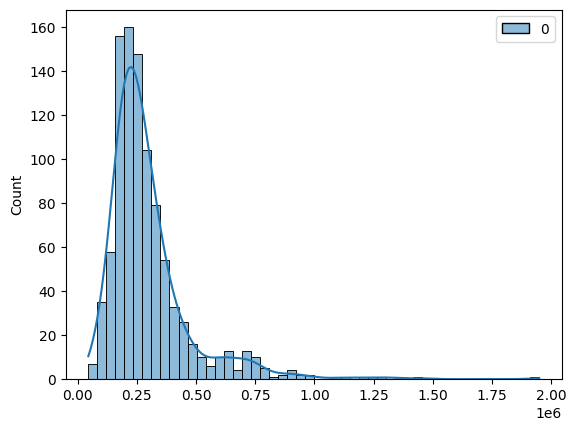

In [7]:
sns.histplot(y_train, color='Blue', kde = True,bins=50)
plt.show()

Distribución del precio con cola derecha pronunciada: la mayoría de viviendas se concentra entre ~200k y ~350k, pero hay un grupo pequeño de anuncios muy caros (outliers) que estiran la cola hasta ~2M.

In [8]:
describe_df(X_train_limpio)

Clasificación sugerida para 966 filas, con un umbral para categórica nominal de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.


,dormitorios,superficie_m2,baños,latitud,longitud,planta,aire_acondicionado,ascensor,calefaccion,ano_construccion,planos,realista,fotografias,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica,categoria_ord,clase_energetica_ord,tiene_certificado
Columnas,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Tipo_Dato,float64,object,float64,float64,float64,float64,str,int64,str,int64,int64,bool,int64,float64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,int64,int64,float64,bool
Nulos,95,0,79,0,0,368,0,0,0,0,0,0,0,306,307,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,306,0
Nulos_%,9.8,0.0,8.2,0.0,0.0,38.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.7,31.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.7,0.0
Cardinalidad,6,161,5,818,940,13,3,2,3,93,2,2,45,431,292,6,77,6,77,6,90,6,112,6,100,6,114,6,115,6,102,2,2,3,7,2
Cardinalidad_%,0.62,16.67,0.52,84.68,97.31,1.35,0.31,0.21,0.31,9.63,0.21,0.21,4.66,44.62,30.23,0.62,7.97,0.62,7.97,0.62,9.32,0.62,11.59,0.62,10.35,0.62,11.8,0.62,11.9,0.62,10.56,0.21,0.21,0.31,0.72,0.21
Clasificacion_sugerida,Categorica,Bajo_Interes,Categorica,Numerica_Continua,Numerica_Continua,Numerica_Discreta,Categorica,Categorica_Binaria,Categorica,Numerica_Discreta,Categorica_Binaria,Categorica_Binaria,Numerica_Discreta,Numerica_Continua,Numerica_Continua,Categorica,Numerica_Discreta,Categorica,Numerica_Discreta,Categorica,Numerica_Discreta,Categorica,Numerica_Continua,Categorica,Numerica_Continua,Categorica,Numerica_Continua,Categorica,Numerica_Continua,Categorica,Numerica_Continua,Categorica_Binaria,Categorica_Binaria,Categorica,Categorica,Categorica_Binaria


In [9]:
binaria = tipifica_variables(X_train_limpio)['Categorica_Binaria']
categorica = tipifica_variables(X_train_limpio)['Categorica']
num_discreta = tipifica_variables(X_train_limpio)['Numerica_Discreta']
num_continua = tipifica_variables(X_train_limpio)['Numerica_Continua']
numericas = num_discreta + num_continua

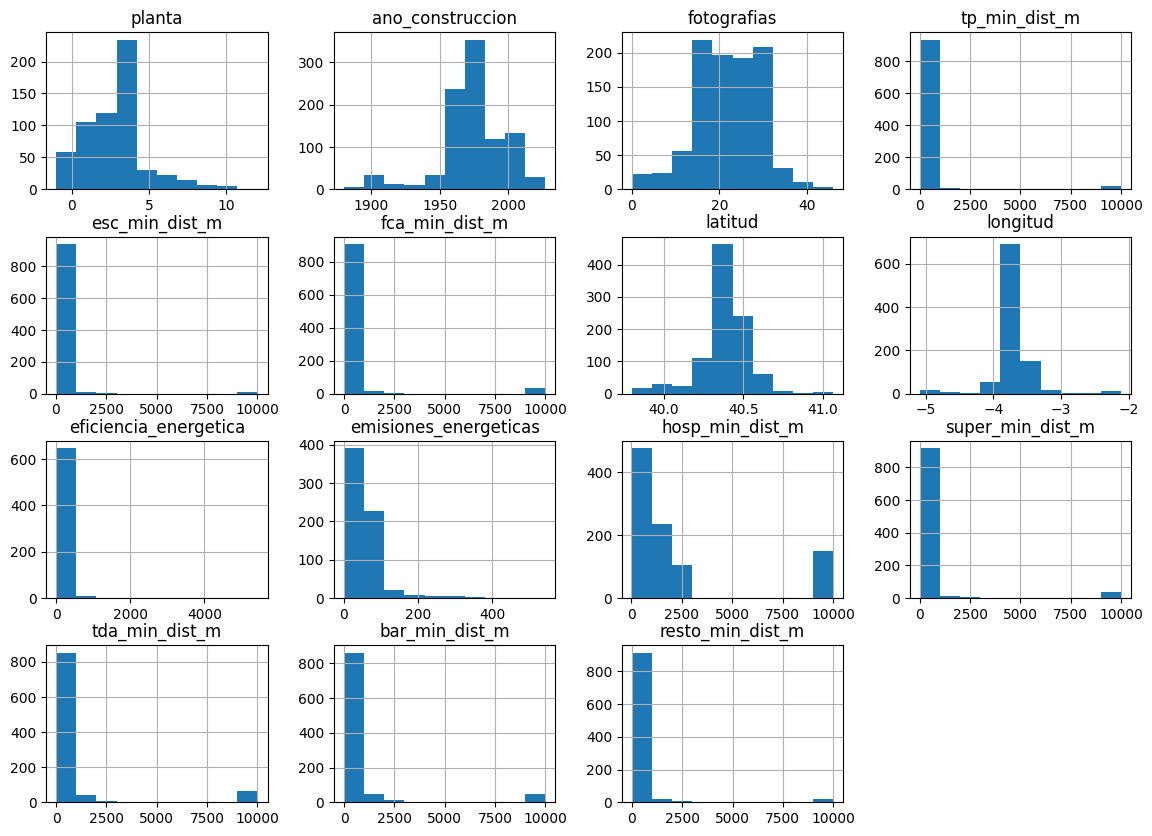

In [10]:
X_train_limpio[numericas].hist(figsize=(14, 10));

### Comparación de modelos

In [ ]:
num_sel = make_column_selector(dtype_include = np.number)
cat_sel = make_column_selector(dtype_include = object)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
            ]), num_sel),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel),
    ],
    remainder='drop',
).set_output(transform="pandas")

preprocess_scale = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_sel),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel),

    ],
    remainder='drop'
).set_output(transform="pandas")

preprocess.fit_transform(X_train_limpio1)

TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['float', 'str']

In [12]:
models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForest': RandomForestRegressor(max_depth=5, random_state=42),
    'XGBRegressor': XGBRegressor(max_depth=5, random_state=42, objective='reg:absoluteerror',),
    'LGBMRegressor': LGBMRegressor(max_depth=5, random_state=42, verbosity=-1),
    'CatBoostRegressor': CatBoostRegressor(depth=5, random_state=42, loss_function='MAPE', verbose=False, train_dir='catboost_tmp'),
}


results = []

for name, model in models.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess), ("model", model)])

    # pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1) # Varía el como se ajusta el modelo, discutir.

    scores = cross_val_score(pipe, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores                 
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

Entrenando DecisionTree...
Entrenando RandomForest...
Entrenando XGBRegressor...
Entrenando LGBMRegressor...
Entrenando CatBoostRegressor...


In [13]:
models_scale = {
    'lr_reg' : LinearRegression(),
    'knn_reg_3' : KNeighborsRegressor(n_neighbors= 3),
    'knn_reg_5' : KNeighborsRegressor(n_neighbors= 5),
}


for name, model in models_scale.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess_scale), ("model", model)])

    # pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    scores_scale = cross_val_score(pipe, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores_scale                
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_MAPE')
results_df

Entrenando lr_reg...
Entrenando knn_reg_3...
Entrenando knn_reg_5...


,model,mean_MAPE
3,LGBMRegressor,0.191586
2,XGBRegressor,0.201832
1,RandomForest,0.240599
4,CatBoostRegressor,0.262846
0,DecisionTree,0.276351
7,knn_reg_5,0.295429
6,knn_reg_3,0.299085
5,lr_reg,0.459391


In [14]:
models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForest': RandomForestRegressor(max_depth=5, random_state=42),
    'XGBRegressor': XGBRegressor(max_depth=5, random_state=42, objective='reg:absoluteerror',),
    'LGBMRegressor': LGBMRegressor(max_depth=5, random_state=42, verbosity=-1),
    'CatBoostRegressor': CatBoostRegressor(depth=5, random_state=42, loss_function='MAPE', verbose=False, train_dir='catboost_tmp'),
}


results = []

for name, model in models.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess), ("model", model)])

    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1) # Varía el como se ajusta el modelo, discutir.

    scores = cross_val_score(pipe_log, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores                 
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

Entrenando DecisionTree...
Entrenando RandomForest...
Entrenando XGBRegressor...
Entrenando LGBMRegressor...
Entrenando CatBoostRegressor...


In [15]:
models_scale = {
    'lr_reg' : LinearRegression(),
    'knn_reg_3' : KNeighborsRegressor(n_neighbors= 3),
    'knn_reg_5' : KNeighborsRegressor(n_neighbors= 5),
}


for name, model in models_scale.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess_scale), ("model", model)])

    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    scores_scale = cross_val_score(pipe_log, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores_scale                
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_MAPE')
results_df

Entrenando lr_reg...
Entrenando knn_reg_3...
Entrenando knn_reg_5...


,model,mean_MAPE
3,LGBMRegressor,1.670340e-01
4,CatBoostRegressor,1.698774e-01
2,XGBRegressor,1.760376e-01
1,RandomForest,2.057668e-01
0,DecisionTree,2.664753e-01
7,knn_reg_5,2.682440e-01
6,knn_reg_3,2.790585e-01
5,lr_reg,2.636646e+20


En la comparación inicial, el mejor desempeño lo obtuvo CatBoostRegressor con un RMSE medio de aproximadamente 85.000 €, seguido por XGBoost (~94.000 €), Random Forest (~98.000 €) y LightGBM (~102.000 €); en cambio, KNN quedó bastante por detrás (~136–139k) y la regresión lineal fue claramente la peor (~340k), lo que sugiere que la relación entre las variables y el precio no es lineal y que los modelos basados en árboles y boosting capturan mejor interacciones y no linealidades.   

Al analizar la distribución del precio objetivo, se observa un mínimo cercano a 44.900 €, una mediana alrededor de 250.000 €, un percentil 75 de aproximadamente 338.000 € y un máximo de 1.950.000 €, muy extremo respecto del resto, lo que indica una distribución asimétrica con cola derecha y presencia de outliers(como vimos en el grafico del target anteriormente). En este contexto, un RMSE de ~85.000 € puede parecer relativamente “aceptable” en el rango central (aprox. 250–338k), pero resulta muy grande en términos relativos para viviendas baratas (por ejemplo, cerca de 45k implica errores comparables o incluso superiores al propio precio), por lo que además de RMSE conviene incorporar métricas de error relativo (como MAPE o MAE/mediana) y revisar si los modelos fallan de forma desproporcionada en los extremos (viviendas muy caras o muy baratas).

### Ajuste de hiperparametros

In [16]:
# cat_base = CatBoostRegressor(random_state=42, loss_function="RMSE",verbose=False,)

# pipe_cat = Pipeline(steps=[
#         ('features', pipe_features),
#         ('preprocess', preprocess),
#         ("model", cat_base),
#     ])


# param_grid_cat = {
#     'model__depth': [4, 6, 8, 10],
#     'model__learning_rate': [0.03, 0.05, 0.1],
#     'model__iterations': [400, 800, 1200],
#     'model__l2_leaf_reg': [1, 3, 5, 7, 9],
#     'model__subsample': [0.7, 0.85, 1.0],
#     'model__random_strength': [0.5, 1.0, 2.0],
# }

# grid_cat = GridSearchCV(
#     estimator = pipe_cat,
#     param_grid = param_grid_cat,
#     cv = 5,
#     scoring = 'neg_root_mean_squared_error',
#     n_jobs = -1,
#     verbose = 1,
# )

# grid_cat.fit(X_train, y_train)

# best_rmse = -grid_cat.best_score_

# print("Mejores hiperparámetros:", grid_cat.best_params_)
# print("Mejor RMSE CV:", best_rmse)

In [17]:
# xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)

# pipe_xgb = Pipeline(steps=[
#     ('features', pipe_features),
#     ('preprocess', preprocess),
#     ('model', xgb_base),
# ])

# param_grid_xgb = {
#     'model__n_estimators': [400, 800, 1200],
#     'model__learning_rate': [0.03, 0.05, 0.1],
#     'model__max_depth': [3, 5, 7, 9],
#     'model__min_child_weight': [1, 3, 5],
#     'model__subsample': [0.7, 0.85, 1.0],
#     'model__colsample_bytree': [0.7, 0.85, 1.0],
#     'model__reg_alpha': [0.0, 0.1, 1.0],
#     'model__reg_lambda': [1.0, 3.0, 10.0],
# }

# grid_xgb = GridSearchCV(
#     estimator=pipe_xgb,
#     param_grid=param_grid_xgb,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# grid_xgb.fit(X_train, y_train)

# best_rmse = -grid_xgb.best_score_

# print("Mejores hiperparámetros:", grid_xgb.best_params_)
# print("Mejor RMSE CV:", best_rmse)


In [19]:
def objective_xgb(trial):
    
    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

    params = {
        "model__n_estimators": trial.suggest_int("model__n_estimators", 500, 1200),
        "model__learning_rate": trial.suggest_float("model__learning_rate", 0.01, 0.15, log=True),
        "model__max_depth": trial.suggest_int("model__max_depth", 4, 8),
        "model__min_child_weight": trial.suggest_int("model__min_child_weight", 1, 5),
        "model__subsample": trial.suggest_float("model__subsample", 0.7, 1.0),
        "model__colsample_bytree": trial.suggest_float("model__colsample_bytree", 0.7, 1.0),
        "model__reg_alpha": trial.suggest_float("model__reg_alpha", 1e-3, 1.0, log=True),
        "model__reg_lambda": trial.suggest_float("model__reg_lambda", 1.0, 5.0),
    }
    
    pipe_xgb.set_params(**params)
    
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_xgb_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_percentage_error",
        n_jobs=-1
    ).mean()
    
    return score

study_xgb = create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=50)

best_params_xgb = study_xgb.best_params
best_params_xgb

[I 2026-03-01 08:39:13,712] A new study created in memory with name: no-name-0968132d-2d62-43a8-b1d0-753e0a11bd2f
[I 2026-03-01 08:39:16,352] Trial 0 finished with value: -0.16494507789611818 and parameters: {'model__n_estimators': 512, 'model__learning_rate': 0.02748137381771233, 'model__max_depth': 6, 'model__min_child_weight': 4, 'model__subsample': 0.7171521402258577, 'model__colsample_bytree': 0.9260528887520341, 'model__reg_alpha': 0.017158019708180813, 'model__reg_lambda': 4.486612889302231}. Best is trial 0 with value: -0.16494507789611818.
[I 2026-03-01 08:39:19,492] Trial 1 finished with value: -0.15946153700351715 and parameters: {'model__n_estimators': 1032, 'model__learning_rate': 0.039455162429424984, 'model__max_depth': 7, 'model__min_child_weight': 5, 'model__subsample': 0.8055569438100902, 'model__colsample_bytree': 0.919798630238471, 'model__reg_alpha': 0.0435662791118102, 'model__reg_lambda': 4.349970083503585}. Best is trial 1 with value: -0.15946153700351715.
[I 20

{'model__n_estimators': 1196,
 'model__learning_rate': 0.027015978479687716,
 'model__max_depth': 7,
 'model__min_child_weight': 3,
 'model__subsample': 0.8078137274456954,
 'model__colsample_bytree': 0.766875661160019,
 'model__reg_alpha': 0.03497989807225667,
 'model__reg_lambda': 1.9379459144933928}

In [19]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb.set_params(**best_params_xgb)

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

pipe_xgb_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...=None, ...))])"
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...002A488C0FB00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity fu

In [20]:
mean_absolute_percentage_error(y_test, pipe_xgb_log.predict(X_test))

0.16625116765499115

XGBoost: 0.1663 -> 2m53s

XGBoost optimizado me da un error en el test de 71.130 para el precio en bruto.
75.082 para el precio en log.

In [ ]:
def objective_lgb(trial):
    
    lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, objective='regression', verbosity=-1)
    pipe_lgb = Pipeline(steps=[('preprocess', preprocess), ('model', lgb_base)])
    
    params = {
        "model__n_estimators": trial.suggest_int("model__n_estimators", 500, 1200),
        "model__learning_rate": trial.suggest_float("model__learning_rate", 0.01, 0.15, log=True),
        "model__max_depth": trial.suggest_int("model__max_depth", 4, 12),
        "model__num_leaves": trial.suggest_int("model__num_leaves", 20, 100),
        "model__min_child_samples": trial.suggest_int("model__min_child_samples", 5, 50),
        "model__subsample": trial.suggest_float("model__subsample", 0.7, 1.0),
        "model__colsample_bytree": trial.suggest_float("model__colsample_bytree", 0.7, 1.0),
        "model__reg_alpha": trial.suggest_float("model__reg_alpha", 1e-3, 1.0, log=True),
        "model__reg_lambda": trial.suggest_float("model__reg_lambda", 1.0, 5.0),
    }
    
    pipe_lgb.set_params(**params)
    
    pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_lgb_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_percentage_error",
        n_jobs=-1
    ).mean()
    
    return score

study_lgb = create_study(direction="maximize")
study_lgb.optimize(objective_lgb, n_trials=50)

best_params_lgb = study_lgb.best_params
best_params_lgb

[I 2026-02-28 10:48:34,662] A new study created in memory with name: no-name-409c3321-e63b-48a2-820c-78416a75d7a7
[I 2026-02-28 10:48:37,813] Trial 0 finished with value: -0.166560152869708 and parameters: {'model__n_estimators': 677, 'model__learning_rate': 0.09378637064424682, 'model__max_depth': 9, 'model__num_leaves': 44, 'model__min_child_samples': 21, 'model__subsample': 0.9692098294377504, 'model__colsample_bytree': 0.8455632620755772, 'model__reg_alpha': 0.6028421767911641, 'model__reg_lambda': 3.728084945514005}. Best is trial 0 with value: -0.166560152869708.
[I 2026-02-28 10:48:42,920] Trial 1 finished with value: -0.16516386664408328 and parameters: {'model__n_estimators': 1134, 'model__learning_rate': 0.02796912612113567, 'model__max_depth': 10, 'model__num_leaves': 89, 'model__min_child_samples': 12, 'model__subsample': 0.717400760439017, 'model__colsample_bytree': 0.8959178938102285, 'model__reg_alpha': 0.020244847252601932, 'model__reg_lambda': 4.567016291498842}. Best 

{'model__n_estimators': 1136,
 'model__learning_rate': 0.02982513770247493,
 'model__max_depth': 9,
 'model__num_leaves': 70,
 'model__min_child_samples': 27,
 'model__subsample': 0.7012698024287148,
 'model__colsample_bytree': 0.7186800885537047,
 'model__reg_alpha': 0.01298021007209539,
 'model__reg_lambda': 1.5020641331381845}

In [22]:
lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, objective='regression', verbosity=-1)
pipe_lgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', lgb_base)])

pipe_lgb.set_params(**best_params_lgb)

pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)

pipe_lgb_log.fit(X_train, y_train)

c:\Users\phbas\Documents\Bootcamp_Data_Science\ML_Prediccion_Precio_Vivienda_Madrid\venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...rbosity=-1))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...002A488C0FB00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity func

In [23]:
mean_absolute_percentage_error(y_test, pipe_lgb_log.predict(X_test))

0.17081989198543515

LightGBoost: 0.1708 -> 3m10s

In [24]:
def objective_cat(trial):

    cat_base = CatBoostRegressor(random_state=42, loss_function="MAPE",verbose=False,)
    pipe_cat = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ("model", cat_base)])

    params = {
        "model__depth": trial.suggest_int("model__depth", 6, 10),
        "model__learning_rate": trial.suggest_float("model__learning_rate", 0.01, 0.15, log=True),
        "model__iterations": trial.suggest_int("model__iterations", 500, 1200),
        "model__l2_leaf_reg": trial.suggest_float("model__l2_leaf_reg", 1.0, 10.0),
        "model__subsample": trial.suggest_float("model__subsample", 0.7, 1.0),
        "model__random_strength": trial.suggest_float("model__random_strength", 0.5, 2.0),
    }
    
    pipe_cat.set_params(**params)

    pipe_cat_log = TransformedTargetRegressor(regressor=pipe_cat, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_cat_log,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_percentage_error",
        n_jobs=-1
    ).mean()
    
    return score

study_cat = create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=50)

best_params_cat = study_cat.best_params
best_params_cat

[I 2026-02-28 10:51:47,675] A new study created in memory with name: no-name-f4acea2c-66c2-4fc1-a0f7-84a6c3228024
[I 2026-02-28 10:51:52,653] Trial 0 finished with value: -0.17426265257715565 and parameters: {'model__depth': 7, 'model__learning_rate': 0.017174789745694533, 'model__iterations': 597, 'model__l2_leaf_reg': 4.382523357785557, 'model__subsample': 0.846258857886375, 'model__random_strength': 1.58751566772159}. Best is trial 0 with value: -0.17426265257715565.
[I 2026-02-28 10:52:08,625] Trial 1 finished with value: -0.18264931953202188 and parameters: {'model__depth': 9, 'model__learning_rate': 0.05669501737532666, 'model__iterations': 795, 'model__l2_leaf_reg': 6.895689873352138, 'model__subsample': 0.947717868443974, 'model__random_strength': 1.868397980182446}. Best is trial 0 with value: -0.17426265257715565.
[I 2026-02-28 10:52:17,715] Trial 2 finished with value: -0.18145147173039752 and parameters: {'model__depth': 8, 'model__learning_rate': 0.09057794878955736, 'mode

{'model__depth': 6,
 'model__learning_rate': 0.08616478650037739,
 'model__iterations': 949,
 'model__l2_leaf_reg': 9.832110148374703,
 'model__subsample': 0.8966043904014459,
 'model__random_strength': 1.0330322519286084}

In [25]:
cat_base = CatBoostRegressor(random_state=42, loss_function="MAPE", verbose=False)
pipe_cat = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', cat_base)])

pipe_cat.set_params(**best_params_cat)

pipe_cat_log = TransformedTargetRegressor(regressor=pipe_cat, func=np.log1p, inverse_func=np.expm1)

pipe_cat_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...bose=False))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...002A488C0FB00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity func

In [26]:
mean_absolute_percentage_error(y_test, pipe_cat_log.predict(X_test))

0.17092602052022246

CatBoost: 0.1709 -> 8m50s

CatBoost optimizado me da un error en el test de 78.892

Parece que XGBoost es el que mejor resultados nos da, ahora toca entrenar el modelo completo y performarlo, pero primero hagamos un estudio de rendimiento para obtener un modelo más ligero con una seleccion de features inteligente:

In [82]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_preprocess = Pipeline(steps=[('features', pipe_features)])

X_preprocessed = pipe_preprocess.fit_transform(X)

xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

start = time()
pipe_xgb_log.fit(X_preprocessed, y)
train_time = [(time() - start)]

score = [cross_val_score(pipe_xgb_log, X_preprocessed, y, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean()]

pd.DataFrame({'score': score, 'time': train_time}).sort_values('score')

,score,time
0,-0.180446,0.083199


In [84]:
lista_col = []
train_time = []
score = []

xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

for col in X_preprocessed.columns:

    lista_col.append(col)
    X_opt = X_preprocessed.drop(columns=col)

    start = time()
    pipe_xgb_log.fit(X_opt, y)
    train_time.append(time() - start)

    score.append(cross_val_score(pipe_xgb_log, X_opt, y, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean())


pd.DataFrame({'columna': lista_col, 'score': score, 'time': train_time}).sort_values('score', ascending=False).iloc[0]['columna']

'resto_min_dist_m'

In [81]:
X_preprocessed = X_preprocessed.drop(columns='resto_min_dist_m')

lista_col = []
train_time = []
score = []

xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

for col in X_preprocessed.columns:

    lista_col.append(col)
    X_opt = X_preprocessed.drop(columns=col)

    start = time()
    pipe_xgb_log.fit(X_opt, y)
    train_time.append(time() - start)

    score.append(cross_val_score(pipe_xgb_log, X_opt, y, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean())


pd.DataFrame({'columna': lista_col, 'score': score, 'time': train_time}).sort_values('score', ascending=False).iloc[0]

KeyError: "['resto_min_dist_m'] not found in axis"

In [88]:
X_preprocessed

,dormitorios,superficie_m2,baños,latitud,longitud,planta,aire_acondicionado,ascensor,calefaccion,ano_construccion,planos,realista,fotografias,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica,categoria_ord,clase_energetica_ord,tiene_certificado
0,3.0,120.0,2.0,40.614302,-3.723223,NaN,NO,1,NO,2011,0,False,16,NaN,NaN,3,460.0,5,320.0,1,950.0,0,10000.0,5,1100.0,1,1500.0,5,1400.0,5,860.0,0,0,0,NaN,False
1,NaN,105.0,2.0,39.957600,-3.496170,NaN,Independiente,0,NO,1987,1,False,32,24.50,35.10,2,250.0,4,320.0,2,170.0,0,10000.0,3,90.0,5,60.0,5,260.0,5,330.0,0,0,0,3.0,True
2,4.0,70.0,NaN,40.433502,-3.664073,2.0,NO,0,NO,1956,0,False,26,243.00,51.00,5,70.0,5,60.0,5,60.0,5,730.0,5,290.0,5,100.0,5,80.0,5,340.0,0,0,2,2.0,True
3,NaN,99.0,1.0,40.405902,-3.612902,NaN,NO,0,NO,1984,1,False,19,NaN,NaN,5,40.0,5,240.0,5,90.0,3,2200.0,5,290.0,5,520.0,5,70.0,5,750.0,0,0,0,NaN,False
4,2.0,63.0,1.0,40.401802,-3.691282,0.0,NO,0,Independiente,1925,1,False,20,295.00,50.00,5,190.0,5,310.0,5,70.0,5,1800.0,5,150.0,5,70.0,5,110.0,5,60.0,0,1,1,2.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,3.0,100.0,2.0,40.365902,-3.698932,NaN,Independiente,0,Independiente,1994,0,False,25,112.00,22.80,5,90.0,5,90.0,5,50.0,1,1100.0,5,590.0,5,550.0,5,660.0,5,610.0,1,0,0,3.0,True
1214,1.0,72.0,1.0,40.549202,-3.324873,0.0,NO,0,Independiente,1989,0,False,18,60.26,10.24,2,160.0,5,150.0,4,170.0,0,10000.0,3,550.0,1,1100.0,3,310.0,0,10000.0,0,0,0,5.0,True
1215,NaN,54.0,1.0,40.428102,-3.638793,NaN,NO,0,NO,1970,0,False,11,210.00,35.00,4,160.0,5,40.0,5,50.0,5,970.0,5,300.0,5,480.0,5,380.0,5,420.0,0,0,0,2.0,True
1216,NaN,66.0,1.0,40.429402,-3.638183,2.0,NO,0,NO,1965,0,False,16,152.00,51.00,4,70.0,5,140.0,5,130.0,5,840.0,5,310.0,5,440.0,5,470.0,5,400.0,0,0,0,2.0,True


In [96]:
def performar_tiempo(X, col=None):

    if col:
        X = X.drop(columns=col)

    lista_col = []
    train_time = []
    score = []

    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

    for col in X.columns:

        lista_col.append(col)
        X_menos = X.drop(columns=col)

        start = time()
        pipe_xgb_log.fit(X_menos, y)
        train_time.append(time() - start)

        score.append(cross_val_score(pipe_xgb_log, X_menos, y, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean())
    
    resultados = pd.DataFrame({'columna': lista_col, 'score': score, 'time': train_time}).set_index('columna').sort_values('score', ascending=False).iloc[0]

    if len(X.columns) > 2:
        print(f'Eliminamos {resultados.name}...')
        resultados = pd.concat([resultados, performar_tiempo(X, col=resultados.name)], axis=1)

    return resultados

resultados_funcion = performar_tiempo(X_preprocessed)
resultados_funcion

Eliminamos resto_min_dist_m...
Eliminamos tda_min_dist_m...
Eliminamos clase_energetica_ord...
Eliminamos bar_cnt...
Eliminamos resto_cnt...
Eliminamos fotografias...
Eliminamos realista...
Eliminamos tiene_certificado...
Eliminamos calefaccion_electrica...
Eliminamos super_min_dist_m...
Eliminamos aire_acondicionado...
Eliminamos super_cnt...
Eliminamos planos...
Eliminamos esc_cnt...
Eliminamos tda_cnt...
Eliminamos fca_min_dist_m...
Eliminamos tp_min_dist_m...
Eliminamos categoria_ord...
Eliminamos calefaccion_gas...
Eliminamos eficiencia_energetica...
Eliminamos esc_min_dist_m...
Eliminamos bar_min_dist_m...
Eliminamos emisiones_energeticas...
Eliminamos baños...
Eliminamos hosp_cnt...
Eliminamos hosp_min_dist_m...
Eliminamos ascensor...
Eliminamos fca_cnt...
Eliminamos dormitorios...
Eliminamos calefaccion...
Eliminamos planta...
Eliminamos ano_construccion...
Eliminamos tp_cnt...
Eliminamos longitud...


,resto_min_dist_m,tda_min_dist_m,clase_energetica_ord,bar_cnt,resto_cnt,fotografias,realista,tiene_certificado,calefaccion_electrica,super_min_dist_m,aire_acondicionado,super_cnt,planos,esc_cnt,tda_cnt,fca_min_dist_m,tp_min_dist_m,categoria_ord,calefaccion_gas,eficiencia_energetica,esc_min_dist_m,bar_min_dist_m,emisiones_energeticas,baños,hosp_cnt,hosp_min_dist_m,ascensor,fca_cnt,dormitorios,calefaccion,planta,ano_construccion,tp_cnt,longitud,superficie_m2
score,-0.176442,-0.175658,-0.173853,-0.173536,-0.172666,-0.171068,-0.171068,-0.171068,-0.172898,-0.172877,-0.172441,-0.172358,-0.171617,-0.172667,-0.173259,-0.173194,-0.173060,-0.173154,-0.173196,-0.172453,-0.176735,-0.173731,-0.169700,-0.169344,-0.172386,-0.176375,-0.177600,-0.177723,-0.177148,-0.180481,-0.183181,-0.183357,-0.192888,-0.262496,-0.323137
time,0.091962,0.097252,0.085082,0.085821,0.088403,0.085876,0.086736,0.100909,0.087332,0.073744,0.084046,0.080208,0.074333,0.075941,0.078005,0.078619,0.100677,0.076897,0.066683,0.066656,0.067169,0.070225,0.064262,0.056251,0.060162,0.070457,0.066276,0.049719,0.059661,0.063925,0.045136,0.061394,0.045169,0.055151,0.040442


KeyError: 0

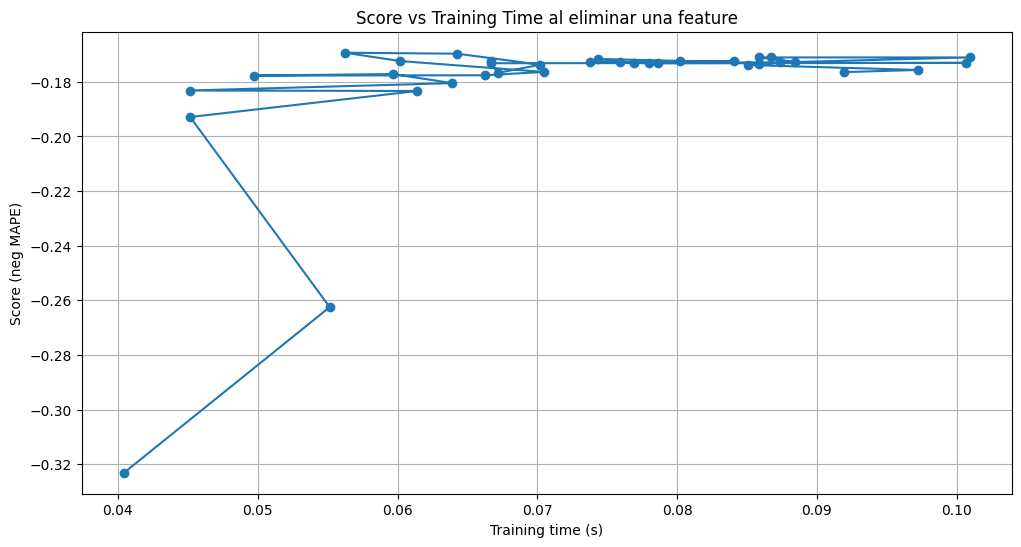

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos que pegaste
data_dict = {
    'resto_min_dist_m': [-0.176442, 0.091962],
    'tda_min_dist_m': [-0.175658, 0.097252],
    'clase_energetica_ord': [-0.173853, 0.085082],
    'bar_cnt': [-0.173536, 0.085821],
    'resto_cnt': [-0.172666, 0.088403],
    'fotografias': [-0.171068, 0.085876],
    'realista': [-0.171068, 0.086736],
    'tiene_certificado': [-0.171068, 0.100909],
    'calefaccion_electrica': [-0.172898, 0.087332],
    'super_min_dist_m': [-0.172877, 0.073744],
    'aire_acondicionado': [-0.172441, 0.084046],
    'super_cnt': [-0.172358, 0.080208],
    'planos': [-0.171617, 0.074333],
    'esc_cnt': [-0.172667, 0.075941],
    'tda_cnt': [-0.173259, 0.078005],
    'fca_min_dist_m': [-0.173194, 0.078619],
    'tp_min_dist_m': [-0.173060, 0.100677],
    'categoria_ord': [-0.173154, 0.076897],
    'calefaccion_gas': [-0.173196, 0.066683],
    'eficiencia_energetica': [-0.172453, 0.066656],
    'esc_min_dist_m': [-0.176735, 0.067169],
    'bar_min_dist_m': [-0.173731, 0.070225],
    'emisiones_energeticas': [-0.169700, 0.064262],
    'baños': [-0.169344, 0.056251],
    'hosp_cnt': [-0.172386, 0.060162],
    'hosp_min_dist_m': [-0.176375, 0.070457],
    'ascensor': [-0.177600, 0.066276],
    'fca_cnt': [-0.177723, 0.049719],
    'dormitorios': [-0.177148, 0.059661],
    'calefaccion': [-0.180481, 0.063925],
    'planta': [-0.183181, 0.045136],
    'ano_construccion': [-0.183357, 0.061394],
    'tp_cnt': [-0.192888, 0.045169],
    'longitud': [-0.262496, 0.055151],
    'superficie_m2': [-0.323137, 0.040442]
}

# Crear DataFrame
df = pd.DataFrame(data_dict, index=['score', 'time']).T  # Transponemos para tener features en filas

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['time'], df['score'], marker='o', linestyle='-')
plt.xlabel('Training time (s)')
plt.ylabel('Score (neg MAPE)')
plt.title('Score vs Training Time al eliminar una feature')
plt.grid(True)

# Opcional: añadir etiquetas de las features en los puntos
for i, feature in enumerate(df.index):
    plt.text(df['time'][i], df['score'][i], feature, fontsize=8, rotation=45, ha='right', va='bottom')

plt.tight_layout()
plt.show()

Entre las conclusiones podemos decir que el entrenar el modelo como un pipeline completo es muy beneficioso para dejar un modelo listo para producción y totalmente automatizado, con la minima posibilidad de error, pero también conviene destacar que durante las pruebas y para la optimización de hiperparametros castiga mucho el primer paso del pipeline que tiene que desgranar las features y eso le lleva el mayor tiempo de todos los procesos siendo siempre el mismo proceso y resultado, habría que estudiar si podemos hacer este paso antes para que no forme parte del todo del pipeline...

In [66]:
resultados_df.sort_values('score')

,columna,score,time
1,superficie_m2,-0.207358,0.094543
4,longitud,-0.205844,0.089649
3,latitud,-0.202571,0.090766
22,hosp_min_dist_m,-0.185870,0.096266
9,ano_construccion,-0.183744,0.078413
12,fotografias,-0.182931,0.090827
25,tda_cnt,-0.182347,0.108317
17,esc_cnt,-0.182008,0.086196
31,calefaccion_gas,-0.181997,0.102238
26,tda_min_dist_m,-0.181114,0.099954


In [ ]:
RFR_selection = RandomForestRegressor(random_state=42, n_jobs=-1, objective='regression')
pipe_lgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', RFR_selection)])

pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)

pipe_lgb_log.fit(X, y)

AttributeError: 'TransformedTargetRegressor' object has no attribute 'feature_importance'